The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


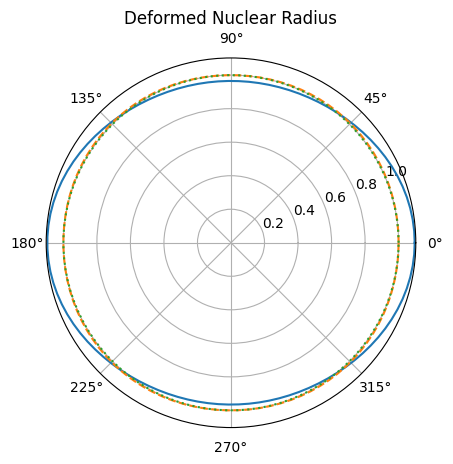

/tmp/ipykernel_69785/3950434611.py:76: RuntimeWarning: divide by zero encountered in divide
  V_so_sph=-lambdapi2*U_so*1./r*(np.exp((r-R_so)/a_so))/(a_so*(np.exp((r-R_so)/a_so)+1)**2)*ldot2s; # [MeV]
/tmp/ipykernel_69785/3950434611.py:76: RuntimeWarning: invalid value encountered in multiply
  V_so_sph=-lambdapi2*U_so*1./r*(np.exp((r-R_so)/a_so))/(a_so*(np.exp((r-R_so)/a_so)+1)**2)*ldot2s; # [MeV]


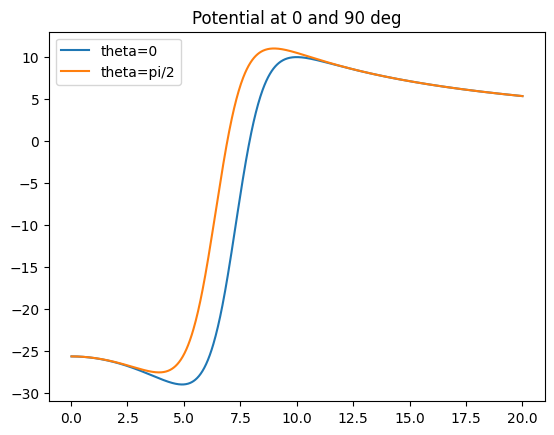

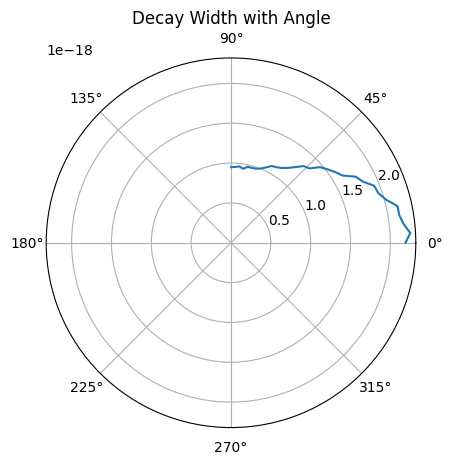

Deformed Nucleon Emitter Results:
Result: Half-life T1/2 = 3.680e-04 s


In [ ]:
# ======================================
# Deformed Nucleon Emitter 
# Hanlin Wang, 2025 Autumn
# ----------------------------
# python: 3.12.1  
# ======================================

# 自动更新函数库的修改
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import myfuncs as mf

# Physical constants and functions 
c=2.99752458e23; # [fm/s] speed of light
hbar=6.5821220e-22; # hbar. [MeV s]
hbar2=4.3324298027314e-43; # hbar^2. unit: [MeV^2 s^2]
epsilon0=8.854187817e-12; # 真空介电常数 (unit: SI)
e0=1.602176634e-19; # elementary charge [C]
alpha=0.0072973525693; # Fine Structure Constant [ ] 
Y00=lambda theta: 1/2*np.sqrt(1/np.pi)+0*np.cos(theta)
Y10=lambda theta: 1/2*np.sqrt(3/np.pi)*np.cos(theta)
Y20=lambda theta: 1/4*np.sqrt(5/np.pi)*(3*(np.cos(theta))**2-1)
Y30=lambda theta: 1/4*np.sqrt(7/np.pi)*(5*(np.cos(theta))**3-3*np.cos(theta))
Y40=lambda theta: 3/16*np.sqrt(1/np.pi)*(35*(np.cos(theta))**4-30*(np.cos(theta))**2+3)
dY20dtheta=lambda theta: -1/4*np.sqrt(5/np.pi)*(6*np.cos(theta)*np.sin(theta))
dY40dtheta=lambda theta: 3/16*np.sqrt(1/np.pi)*(-140*(np.cos(theta))**3*np.sin(theta)+60*np.sin(theta)*np.cos(theta))

# Input parameters
# 151Lu
Ad=150; # Mass number of daughter nucleus
Zd=70;  # Proton number of daughter nucleus
MassExcess=-38.8 # Mass excess of daughter nucleus [MeV]
Qp=1.241; # Decay energy [MeV]
lp=5
jp=lp+0.5
beta2=-0.167
beta4=-0.035
tildebeta2, tildebeta4=0,0
Sp=0.49 # spectroscopic factor
# 161Re
Ad=160; # Mass number of daughter nucleus
Zd=74;  # Proton number of daughter nucleus
MassExcess=-21.33 # Mass excess of daughter nucleus [MeV]
Qp=1.197; # Decay energy [MeV]
lp=0
jp=lp+0.5
beta2, beta4=0.128, 0.018
tildebeta2, tildebeta4=0,0
Sp=0.892 # spectroscopic factor
# Derived parameters
Nd=Ad-Zd; # Neutron number of daughter nucleus
E0=Qp*Ad/(Ad+1)
m_daughter=(931.4941*Ad+MassExcess)/c**2 # mass of the rest of nucleus. unit: MeV
m_proton=(931.4941+7288.9710*1e-3)/c**2 # mass of single proton. unit: MeV
mu=m_proton*m_daughter/(m_proton+m_daughter)

# Potential 
Rcoul=1.21*Ad**(1/3) # [fm] Talou 1999 
Rnucl=1.19*Ad**(1/3)*(1-0.116*(Nd-Zd)/Ad)+0.235
a_nucl=0.637; # PRC 92, 024306 (2015)
fac_def=lambda theta: 1 + beta2*Y20(theta) + beta4*Y40(theta)
fac_surf=lambda theta: np.sqrt(1+(beta2*dY20dtheta(theta)/(fac_def(theta)))**2+(beta4*dY40dtheta(theta)/(fac_def(theta)))**2)
fac_pol=lambda theta: 1 + tildebeta2*Y20(theta) + tildebeta4*Y40(theta)
R_WS = lambda theta: Rnucl*fac_def(theta) # [fm]
V_WS = lambda r,R,a: -50/(1+np.exp((r-R)/a)) # [MeV]
# Coulomb potential (spherical)
V_Coul=lambda r: np.piecewise(r,[r<Rcoul, r>=Rcoul], [lambda r: Zd*e0**2/(4*np.pi*epsilon0)/(e0*1e6)*(3*Rcoul**2-r**2)/(2*Rcoul**3*1e-15), lambda r: Zd*e0**2/(4*np.pi*epsilon0)/(r*1e-15)/(e0*1e6)]) # [MeV]
# Spin-Orbit potential
R_so=1.01*Ad**(1/3); a_so=0.75; U_so=6.2; # Talou 1999 
def V_so_sph(r,lp,jp,V_so0,Rso,aso):
    ldot2s=(jp*(jp+1)-lp*(lp+1)-3/4) # l.2s
    lambdapi2=2 # lambda_pi^2=2 fm^2 the wavelength of pion
    V_so_sph=-lambdapi2*U_so*1./r*(np.exp((r-R_so)/a_so))/(a_so*(np.exp((r-R_so)/a_so)+1)**2)*ldot2s; # [MeV]
    return V_so_sph
# Centrifugal potential
V_cent=lambda r,lp: hbar2*lp*(lp+1)/(2*r**2) # [MeV]

# plot: deformation and polarization 
theta_plot=np.linspace(0,2*np.pi,100)
plt.polar(theta_plot,fac_def(theta_plot))
plt.polar(theta_plot,fac_surf(theta_plot), linestyle='--')
plt.polar(theta_plot,fac_pol(theta_plot), linestyle=':')
plt.title("Deformed Nuclear Radius")
plt.show()

# plot: potential at 0 and 90 degree
x=np.linspace(0,20,1000)
V_WS_0=V_WS(x,R_WS(0),a_nucl)
V_WS_90=V_WS(x,R_WS(np.pi/2),a_nucl)
V_Coul_0=V_Coul(x)
V_so_sph_0=V_so_sph(x,lp,jp,U_so,R_so,a_so)
plt.plot(x,V_WS_0+V_Coul_0+V_so_sph_0, label='theta=0')
plt.plot(x,V_WS_90+V_Coul_0+V_so_sph_0, label='theta=pi/2')
plt.legend()
plt.title("Potential at 0 and 90 deg")
plt.show()

# mesh for calculation
r=np.linspace(0.01,200,10000).T # [fm]
dr=r[1]-r[0]

def WKB1(E0,Vtotal,mu,hbar2,dr):
    # Ref. Talou 1999 PRC 60 054318
    # index for 3 classical turning points
    index123=[0,0,0]
    index_Vmin=np.argmin(Vtotal)
    index_Vmax=np.argmax(Vtotal[index_Vmin:])
    index_Vmax=index_Vmax+index_Vmin-1
    index123[0]=np.argmin(abs(Vtotal[:index_Vmin+1]-E0))
    index123[1]=np.argmin(abs(Vtotal[index_Vmin:index_Vmax+1]-E0))
    index123[1]=index123[1]+index_Vmin-1
    index123[2]=np.argmin(abs(Vtotal[index_Vmax:]-E0))
    index123[2]=index123[2]+index_Vmax-1

    k=np.sqrt(2*mu/hbar2*abs(E0-Vtotal)) # momentum
    inte1=np.trapezoid(dr*k[index123[1]:index123[2]+1]) # \int_r1^r2 k(r)dr
    temp=np.meshgrid(k[index123[0]:index123[1]+1],k[index123[0]:index123[1]+1])
    temp=temp[1]
    inte2=np.trapezoid(dr*np.tril(temp))
    inte3=np.trapezoid(dr/k[index123[0]:index123[1]+1]*(np.cos(inte2-np.pi/4))**2)
    NN=1/inte3
    DecayWidth_WKB1=NN*hbar2/(4*mu)*np.exp(-2*inte1)
    return DecayWidth_WKB1

# Calculate in each direction
len_theta=30
theta=np.linspace(0, np.pi/2, len_theta)  # from 0 to 180 degrees
Gamma_theta=np.zeros(len_theta)
V_Coul_0,V_Coul_2,V_Coul_4=mf.Potential_Coul_multip(r,Zd,Rcoul,e0,epsilon0,beta2,beta4)
for ii in range(len_theta):
    V_Coul_theta=V_Coul_0 + V_Coul_2*Y20(theta[ii]) + V_Coul_4*Y40(theta[ii])
    Vtotal_theta=V_WS(r,R_WS(theta[ii]),a_nucl*fac_surf(theta[ii])*fac_pol(theta[ii]))\
        +V_Coul_theta +V_cent(r,lp)\
            +V_so_sph(r,lp,jp,U_so,R_so*fac_def(theta[ii]),a_so*fac_surf(theta[ii])*fac_pol(theta[ii]))
    Gamma_theta[ii] = WKB1(E0,Vtotal_theta,mu,hbar2,dr)

# plot: decay width with angle
plt.polar(theta, Gamma_theta)
plt.title("Decay Width with Angle")
plt.show()

# final results by WKB 
Gamma_ave=np.trapezoid(Gamma_theta*np.sin(theta), theta)
T12=np.log(2)*hbar/ Gamma_ave / Sp # [s]
# print results
print("Deformed Nucleon Emitter Results:")
print("Result: Half-life T1/2 = {:.3e} s".format(T12))




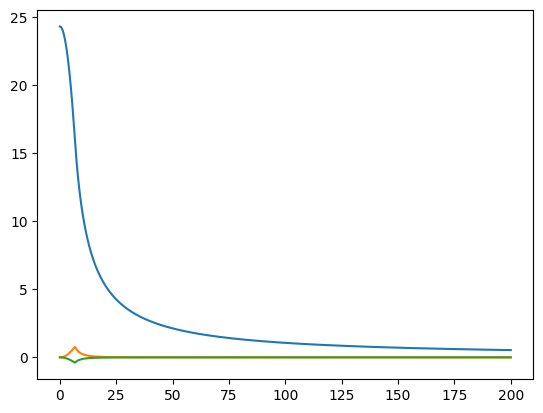

In [3]:

V0,V2,V4=mf.Potential_Coul_multip(r,Zd,Rcoul,e0,epsilon0,beta2,beta4)
plt.plot(r,V0, label='Coulomb 2nd order at 0 deg')
plt.plot(r,V2*Y20(0), label='Coulomb 2nd order at 0 deg')
plt.plot(r,V2*Y20(np.pi/2), label='Coulomb 2nd order at 90 deg')